# scBaseCount lung data summary

## 1. Data import

In [208]:
from __future__ import annotations

import re
from datetime import datetime, timezone
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import matplotlib.pyplot as plt


# Helper function to find the v2_lung directory
def _v2_lung_dir() -> Path:
    """Kernels often start at repo root; relative paths would miss the symlink here."""
    cwd = Path.cwd().resolve()
    if (cwd / "scbasecount_metadata").exists():
        return cwd
    nested = cwd / "metadata_analysis" / "v2_lung"
    if (nested / "scbasecount_metadata").exists():
        return nested
    for parent in [cwd, *cwd.parents]:
        cand = parent / "metadata_analysis" / "v2_lung"
        if (cand / "scbasecount_metadata").exists():
            return cand
    raise FileNotFoundError(
        "Could not find metadata_analysis/v2_lung/scbasecount_metadata; "
        "ensure the symlink exists and the cwd is inside the repo."
    )


# Filepaths to data
OBS_PARQUET = (
    _v2_lung_dir()
    / "scbasecount_metadata"
    / "scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_obs_metadata.parquet"
).resolve()
SAMPLE_PARQUET = (
    _v2_lung_dir()
    / "scbasecount_metadata"
    / "scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_sample_metadata.parquet"
).resolve()

# Read data
obs = pq.ParquetFile(OBS_PARQUET)
sample = pd.read_parquet(SAMPLE_PARQUET)

IMAGES_DIR = (_v2_lung_dir() / "images").resolve()
IMAGES_DIR.mkdir(exist_ok=True)

sample.columns

Index(['entrez_id', 'srx_accession', 'file_path', 'obs_count', 'lib_prep',
       'tech_10x', 'cell_prep', 'organism', 'tissue',
       'tissue_ontology_term_id', 'disease', 'disease_ontology_term_id',
       'perturbation', 'cell_line', 'antibody_derived_tag',
       'czi_collection_id', 'czi_collection_name'],
      dtype='str')

## 2. Regex

In [209]:
# Regex for normal/healthy/control (from v1, with some adaptation for clarity and consistency)
NORMAL_HEALTHY_REGEX = re.compile(
    (
        r"\b(?:"
        r"normal|healthy|control|none|unknown|unstimulated|naive|"
        r"uninvolved|unaffected|unexposed|vehicle|wild[-_\s]?type|"
        r"wt|no treatment|baseline|"
        r"unsure|not specified|not stated|not reported|not available"
        r")\b"
    ), 
    re.IGNORECASE
)

# Regex to match any lung-related disease (malignant or benign)
# Integration inspired by v1's broad inclusion of lung-related disease and tumor terms
LUNG_DISEASE_RE = re.compile(
    (
        r"\b(?:"
        r"lung|pulmonary|NSCLC|SCLC|adenocarcinoma of the lung|mesothelioma|pleura|"
        r"squamous cell carcinoma of the lung|large[- ]cell|bronch|EGFR|(?<!\w)ALK(?!\w)|ROS1|"
        r"thymoma|thymic|"
        r"cancer|carcinoma|adenocarcinoma|sarcoma|tumou?r|malignancy|"
        r"malignant|benign|neoplasm|mass|adenoma|adenomatous|lesion|"
        r"disease|fibrosis|emphysema|asthma|COPD|bronchitis|pneumonia|"
        r"infection|metastasis|injury"
        r")\b"
        r"|"
        r"\b(?:"
        r"emphysema|asthma|COPD|bronchitis|pneumonia|pulmonary fibrosis|"
        r"interstitial lung disease|"
        r"COVID-19|COVID19|COVID 19|sars-cov-2"
        r")\b"
    ),
    re.IGNORECASE
)

# Regex to match any tissue labels related to lung (from v1)
LUNG_TISSUE_RE = re.compile  (
    (
        r"\b(?:"
        r"lung|pulmonary|alveolus|alveoli|bronchus|bronchi|bronchiole|"
        r"airway|respiratory tract|bronchiolar|thoracic|trachea|pleura|"
        r"interstitium|parenchyma"
        r")\b"
    ),
    re.IGNORECASE
)

CANCER_RE = re.compile(
    (
        r"\b(?:"
        r"cancer|carcinoma|adenocarcinoma|sarcoma|tumou?r|malignancy|malignant|"
        r"neoplasm|neoplastic|leukemia|leukaemia|lymphoma|myeloma|melanoma|"
        r"NSCLC|SCLC|mesothelioma|glioblastoma|glioma|blastoma|"
        r"metastasis|metastatic|oncolog"
        r")\b"
    ),
    re.IGNORECASE
)

# Pre-compiled patterns for str.contains: avoids pandas UserWarning on some versions
# (warning checks re.compile(pat); using Pattern + flags in the pattern is reliable).
UNKNOWN_RE = re.compile(
    r"\b(?:unknown|none|unstated|unavailable|ambiguous)\b",
    re.IGNORECASE,
)

## 3. Filter sample df

In [210]:
# Mask for known (not unknown/none/unstated) disease and tissue
unknown_mask = sample[["disease", "tissue"]].apply(lambda col: col.str.contains(NORMAL_HEALTHY_REGEX, na=True)).any(axis=1)
sample_known = sample.loc[unknown_mask == False]

print(unknown_mask.value_counts())

# Filter for any row with a lung-related disease
lung_disease_mask = sample_known["disease"].str.contains(LUNG_DISEASE_RE, regex=True, na=False)

# Filter for any row with a lung-related tissue label
lung_tissue_mask = sample_known["tissue"].str.contains(LUNG_TISSUE_RE, regex=True, na=False)

# Union: samples with lung-related disease OR lung-related tissue
lung_union_mask = lung_disease_mask | lung_tissue_mask
lung_union = sample_known.loc[lung_union_mask].reset_index(drop=True)

# Intersection: samples with BOTH lung-related disease AND lung-related tissue
lung_intersection_mask = lung_disease_mask & lung_tissue_mask
lung_intersection = sample_known.loc[lung_intersection_mask].reset_index(drop=True)

# non-lung rows
not_lung_union = sample_known.loc[lung_union_mask == False].reset_index(drop=True)
not_lung_intersection = sample_known.loc[lung_intersection_mask == False].reset_index(drop=True)

# Cancer subset of lung intersection
lung_intersection_cancer_mask = lung_intersection["disease"].str.contains(CANCER_RE, na=False)
lung_intersection_cancer = lung_intersection.loc[lung_intersection_cancer_mask].reset_index(drop=True)


print(f"sample_known:                  {len(sample_known)}")
print(f"lung union:                    {len(lung_union)}")
print(f"lung intersection:             {len(lung_intersection)}")
print(f"lung intersection (cancer):    {len(lung_intersection_cancer)} ({len(lung_intersection_cancer)/len(lung_intersection):.1%} of intersection)")
print(f"not_lung_union:                {len(not_lung_union)}")
print(f"not_lung_intersection:         {len(not_lung_intersection)}")
print(f"partition check — union:       {len(not_lung_union) + len(lung_union) == len(sample_known)}")
print(f"partition check — intersection:{len(not_lung_intersection) + len(lung_intersection) == len(sample_known)}")

False    18550
True     16716
Name: count, dtype: int64
sample_known:                  18550
lung union:                    7986
lung intersection:             858
lung intersection (cancer):    361 (42.1% of intersection)
not_lung_union:                10564
not_lung_intersection:         17692
partition check — union:       True
partition check — intersection:True


## 4. Summary figures

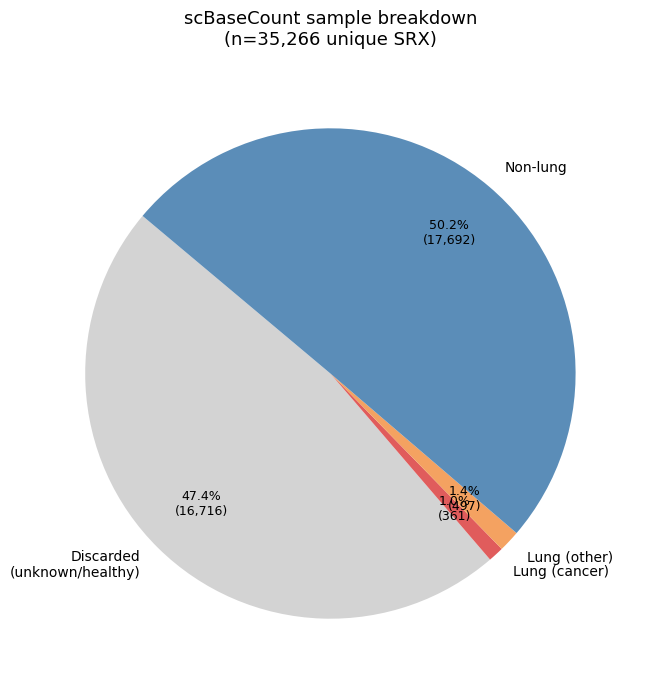

In [211]:
# dataset at a glance
n_total       = len(sample)
n_discarded   = n_total - len(sample_known)
n_lung_cancer = len(lung_intersection_cancer)
n_lung_other  = len(lung_intersection) - n_lung_cancer
n_not_lung    = len(not_lung_intersection)

labels  = [
    "Discarded\n(unknown/healthy)", 
    "Lung (cancer)", 
    "Lung (other)", 
    "Non-lung"
]
sizes   = [n_discarded, n_lung_cancer, n_lung_other, n_not_lung]
colors  = ["#d3d3d3", "#e05c5c", "#f4a261", "#5b8db8"]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * n_total / 100)):,})",
    startangle=140,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(f"scBaseCount sample breakdown\n(n={n_total:,} unique SRX)", fontsize=13, pad=16)
plt.tight_layout()
fig.savefig(IMAGES_DIR / "sample_breakdown.svg", bbox_inches="tight")
plt.show()

In [212]:
# Frequency table of top 20 raw disease and tissue labels
(lung_intersection["tissue"].value_counts(normalize=True) * 100).head(20)
(lung_intersection["disease"].value_counts(normalize=True) * 100).head(20)

disease
lung adenocarcinoma                                                  12.820513
idiopathic pulmonary fibrosis (IPF)                                   8.508159
Idiopathic Pulmonary Fibrosis (IPF)                                   7.459207
SARS-CoV-2 infection                                                  4.662005
idiopathic pulmonary fibrosis                                         3.962704
pulmonary fibrosis                                                    2.913753
COPD                                                                  2.797203
non-small cell lung cancer (NSCLC)                                    2.564103
lung adenocarcinoma (LUAD)                                            2.564103
carcinoma non-small cell                                              1.864802
COVID-19                                                              1.864802
lung cancer                                                           1.515152
cystic fibrosis                             

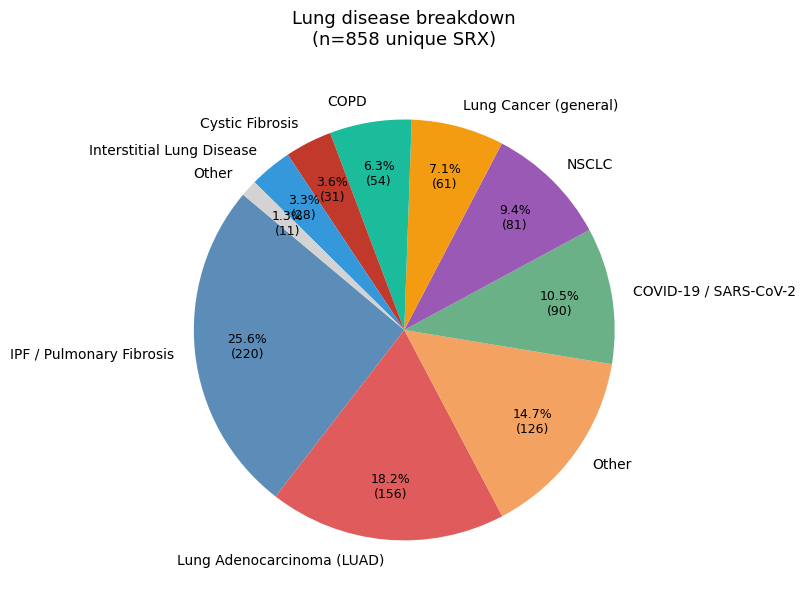

In [213]:
# Lung disease breakdown
disease_map = [
    ("IPF / Pulmonary Fibrosis",     re.compile(r"pulmonary fibrosis|IPF|idiopathic pulmonary fibrosis", re.IGNORECASE)),
    ("COVID-19 / SARS-CoV-2",        re.compile(r"COVID|SARS.CoV", re.IGNORECASE)),
    ("Lung Adenocarcinoma (LUAD)",    re.compile(r"lung adenocarcinoma|LUAD", re.IGNORECASE)),
    ("NSCLC",                         re.compile(r"NSCLC|non.small.cell lung|non.small.cell carcinoma|carcinoma non.small", re.IGNORECASE)),
    ("Lung Squamous Cell Carcinoma",  re.compile(r"squamous cell carcinoma of the lung|lung squamous", re.IGNORECASE)),
    ("COPD",                          re.compile(r"\bCOPD\b", re.IGNORECASE)),
    ("Lung Cancer (general)",         re.compile(r"lung cancer|lung carcinoma|MPLC|KRAS.mutant lung|SCLC", re.IGNORECASE)),
    ("Cystic Fibrosis",               re.compile(r"cystic fibrosis", re.IGNORECASE)),
    ("Interstitial Lung Disease",     re.compile(r"interstitial lung|ILD|SSc", re.IGNORECASE)),
]

def _categorize_disease(d: str) -> str:
    for label, pat in disease_map:
        if pat.search(str(d)):
            return label
    return "Other"

disease_cats = lung_intersection["disease"].map(_categorize_disease)
cat_counts = disease_cats.value_counts()

threshold = 0.02
total_lung = cat_counts.sum()
large = cat_counts[cat_counts / total_lung >= threshold]
small_sum = total_lung - large.sum()
if small_sum > 0:
    large = pd.concat([large, pd.Series({"Other": small_sum})])

palette = [
    "#5b8db8", "#e05c5c", "#f4a261", "#6ab187",
    "#9b59b6", "#f39c12", "#1abc9c", "#c0392b",
    "#3498db", "#d3d3d3",
]


fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    large.values,
    labels=large.index,
    colors=palette[: len(large)],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * total_lung / 100)):,})",
    startangle=140,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title(
    f"Lung disease breakdown\n(n={total_lung:,} unique SRX)",
    fontsize=13,
    pad=16,
)
plt.tight_layout()
fig.savefig(IMAGES_DIR / "lung_disease_breakdown.svg", bbox_inches="tight")
plt.show()

In [214]:
# summary table of number of cells in the dataset
np.sum(lung_intersection["obs_count"])
lung_intersection["obs_count"].describe()

count      858.000000
mean      7126.174825
std       6838.791371
min         45.000000
25%       3151.500000
50%       5124.500000
75%       9186.750000
max      81811.000000
Name: obs_count, dtype: float64

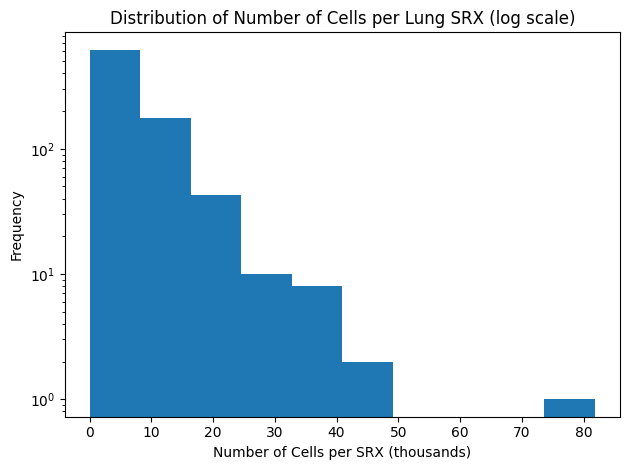

In [215]:
# distribution of number of cells in the dataset
plt.hist(lung_intersection["obs_count"] / 1000, log=True)
plt.title("Distribution of Number of Cells per Lung SRX (log scale)")
plt.xlabel("Number of Cells per SRX (thousands)")
plt.ylabel("Frequency")
plt.tight_layout()
fig = plt.gcf()
fig.savefig(IMAGES_DIR / "lung_cell_number_hist.svg", bbox_inches="tight")